<a href="https://colab.research.google.com/github/ameena0726-ops/House-Price-Prediction/blob/main/task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TASK 3 : HOUSE PRICE PREDICTION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [8]:
from google.colab import files
uploaded = files.upload()

Saving HousingPrices.csv to HousingPrices.csv


In [14]:
df = pd.read_csv("HousingPrices.csv")
print(df.head())   # First Five rows
print(df.tail())   # Last five rows
df.info()
df.describe()      # Statistical Analysis

   Unnamed: 0                                 Address      Zip     Price  \
0           1            Blasiusstraat 8 2, Amsterdam  1091 CR  685000.0   
1           2  Kromme Leimuidenstraat 13 H, Amsterdam  1059 EL  475000.0   
2           3              Zaaiersweg 11 A, Amsterdam  1097 SM  850000.0   
3           4            Tenerifestraat 40, Amsterdam  1060 TH  580000.0   
4           5              Winterjanpad 21, Amsterdam  1036 KN  720000.0   

   Area  Room       Lon        Lat  
0    64     3  4.907736  52.356157  
1    60     3  4.850476  52.348586  
2   109     4  4.944774  52.343782  
3   128     6  4.789928  52.343712  
4   138     5  4.902503  52.410538  
     Unnamed: 0                                Address      Zip     Price  \
919         920                    Ringdijk, Amsterdam  1097 AE  750000.0   
920         921        Kleine Beerstraat 31, Amsterdam  1033 CP  350000.0   
921         922      Stuyvesantstraat 33 II, Amsterdam  1058 AK  350000.0   
922         9

,Unnamed: 0,Price,Area,Room,Lon,Lat
count,924.000000,9.200000e+02,924.000000,924.000000,924.000000,924.000000
mean,462.500000,6.220654e+05,95.952381,3.571429,4.888605,52.363326
std,266.880123,5.389942e+05,57.447436,1.592332,0.053140,0.024028
min,1.000000,1.750000e+05,21.000000,1.000000,4.644819,52.291519
25%,231.750000,3.500000e+05,60.750000,3.000000,4.855834,52.352077
50%,462.500000,4.670000e+05,83.000000,3.000000,4.886818,52.364631
75%,693.250000,7.000000e+05,113.000000,4.000000,4.922337,52.377598
max,924.000000,5.950000e+06,623.000000,14.000000,5.029122,52.423805


In [38]:
df = df.dropna()   # data preprocessing
# Check missing values
print(df.isna().sum())
df = df.dropna(subset=['Price'])
print(df['Price'].dtype)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df = df.dropna(subset=['Price'])


Unnamed: 0    0
Address       0
Zip           0
Price         0
Area          0
Room          0
Lon           0
Lat           0
dtype: int64
float64


In [39]:
# Select features and target
X = df[['Area', 'Room', 'Lon', 'Lat']]
y = df['Price']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
X = df[['Area', 'Room', 'Lon', 'Lat']]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
gb_model.fit(X_train_scaled, y_train)

GradientBoostingRegressor(n_estimators=200, random_state=42)

In [41]:
#Model Evaluation
# Linear Regression evaluation
y_pred_lr = lr_model.predict(X_test_scaled)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# Gradient Boosting evaluation
y_pred_gb = lr_model.predict(X_test_scaled)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print(f"Linear Regression - MAE: {mae_lr}, RMSE: {rmse_lr}")
print(f"Gradient Boosting - MAE: {mae_gb}, RMSE: {rmse_gb}")


Linear Regression - MAE: 164755.88559390572, RMSE: 246897.1956630637
Gradient Boosting - MAE: 164755.88559390572, RMSE: 246897.1956630637


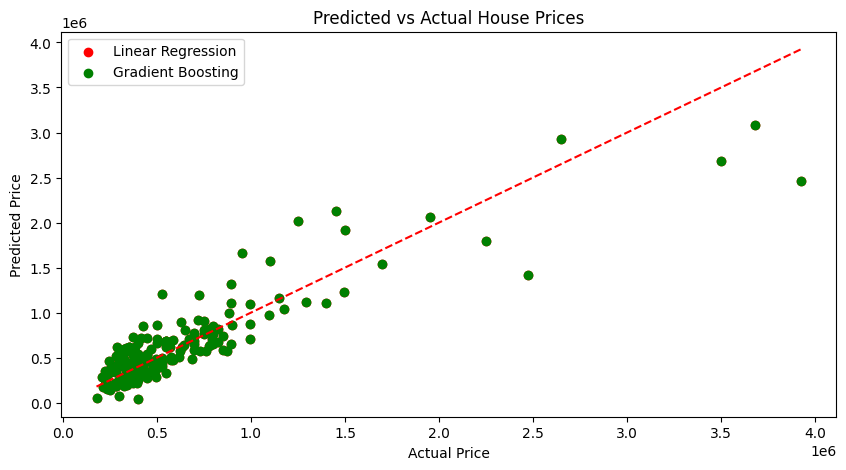

In [43]:
#Visualizatons

plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred_lr, color='red', label='Linear Regression')
plt.scatter(y_test, y_pred_gb, color='green', label='Gradient Boosting')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual House Prices")
plt.legend()
plt.show()


In [45]:
# Predict price for a new house
new_house = pd.DataFrame([[240, 6, 4.98, 52.37]],
                         columns=['Area', 'Room', 'Lon', 'Lat'])

new_house_scaled = scaler.transform(new_house)
predicted_price = gb_model.predict(new_house_scaled)

print("Predicted House Price:", predicted_price)

Predicted House Price: [1185877.11026924]
